# AI-powered Cloud Masking
- Deep learning was used more specifically `UNet++` to detect clouds using binary masks

## Setup Environment  

In [ ]:
from utils import (
    read_and_plot,
    per_band_minmax,
    plot_image_and_mask,
)
from loading import load_image_and_mask
import numpy as np
from segmentation_dataset import SegmentationDataset
import torchvision.transforms as T
from torch.utils.data import DataLoader, random_split, ConcatDataset
from unet_plus_plus import UNetPlusPlus, train_model
import torch.optim as optim
from evaluation import evaluate_and_collect, show_worst_predictions, evaluate_dice_score

import torch

from const import IMAGES_PATH, MASKS_PATH

### Random seeds for reproducibility

In [4]:
np.random.seed(42)
torch.manual_seed(42)

## Exploration Data Analysis
- Some of the images have **mislabeled masks** such as the following images so we need to handle that.
- Mislabeled images occur when the majority of the image is covered with clouds but the mask is **full of zeros or ones**.
- The following 2 images explain that phenomenon as the first mask is full of ones while the second image is full of zeros *(inconsistent behavior)*.

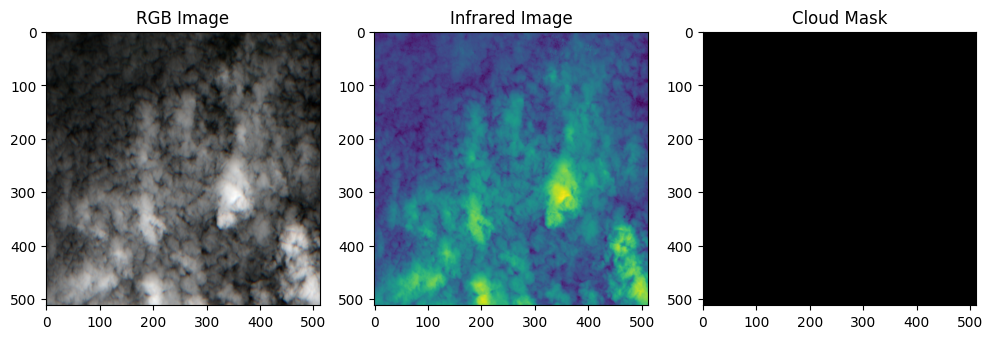

array([1], dtype=uint8)

In [ ]:
image_path, mask_path = read_and_plot(103402)  # bad mask example
image, mask = load_image_and_mask(image_path, mask_path)

image = per_band_minmax(image)
plot_image_and_mask(image, mask)

np.unique(
    mask
)  # print unique values in the mask (should be 0 AND 1) but in the following cases it's 0 OR 1

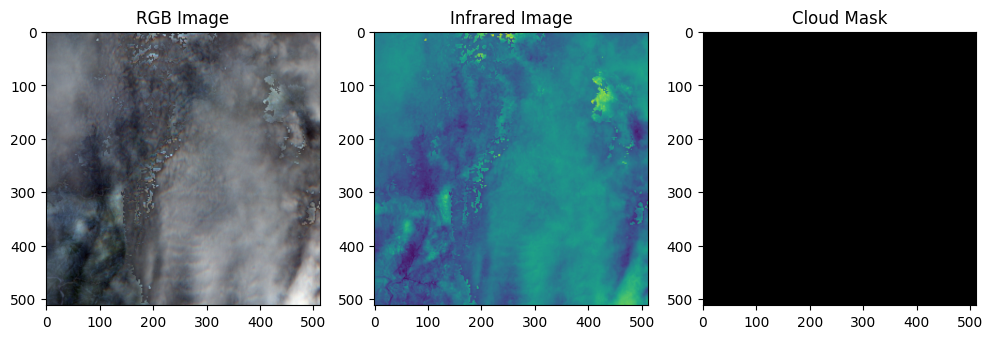

array([0], dtype=uint8)

In [ ]:
image_path, mask_path = read_and_plot(986486)  # another bad mask example
image, mask = load_image_and_mask(image_path, mask_path)

image = per_band_minmax(image)
plot_image_and_mask(image, mask)

np.unique(mask)

## Preprocessing
- We used resizing of the image to be `256*256` instead of `512*512`.
    - This was done to increase the speed of training and reduce the number of parameters.
- We also made a minmax transformation for each band while loading so that each band has values $\in$ [0, 1].
    - This helps so that each band is treated equally without having some band dominate just because it has higher range of values

In [ ]:
transform = T.Compose(
    [
        T.Resize((256, 256)),
    ]
)

## Loading Dataset
- Keep in mind that the minmax transformation is done in `SegmentationDataset` while loading here

In [ ]:
dataset = SegmentationDataset(
    image_dir=IMAGES_PATH,
    mask_dir=MASKS_PATH,
    transform=transform
)

### Train-Validation-Test Split

In [ ]:
# Determining sizes of each set
train_size = int(0.8 * len(dataset))
val_size = int(0.1 * len(dataset))
test_size = len(dataset) - train_size - val_size
len(dataset)

10302

In [ ]:
train_dataset, val_dataset, test_dataset = random_split(
    dataset, [train_size, val_size, test_size]
)

# Create DataLoaders for loaded datasets
batch_size = 8
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=True)
full_data_loader = DataLoader(dataset, batch_size=batch_size, shuffle=True)

In [18]:
np.unique(val_dataset[0][1])

array([False])

In [ ]:
# Testing data loader and checking dimensions
inputs, labels, _ = next(iter(train_loader))
print(
    f"Batch input shape: {inputs.shape}"
)  # Expected: [8, 4, 256, 256] # 8 images, 4 channels, 256*256 pixel
print(
    f"Batch label shape: {labels.shape}"
)  # Expected: [8, 1, 256, 256] # 8 masks, 1 channel, 256*256 pixel

Batch input shape: torch.Size([8, 4, 256, 256])
Batch label shape: torch.Size([8, 1, 256, 256])


## Model Architecture

In [ ]:
# Use GPU if available
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

# Model architecture definition
model = UNetPlusPlus(deep_supervision=False).to(device)

# Optimizer and Scheduler for training and updating both learning rate and weights
optimizer = optim.Adam(
    filter(lambda p: p.requires_grad, model.parameters()), lr=1e-4, weight_decay=1e-4
)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, "min", patience=3, min_lr=1e-6
)

## Training

In [ ]:
trained_model = train_model(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    optimizer=optimizer,
    scheduler=scheduler,
    device=device,
    num_epochs=35,
)

## Exploring Final Model
- Here we check if there's a pattern that the model fails to capture

In [ ]:
# Loading model
model.load_state_dict(torch.load("./dl_9166.pth"))

<All keys matched successfully>

In [ ]:
# Get the cases where the model failed
worst_results = evaluate_and_collect(model, full_data_loader, device)

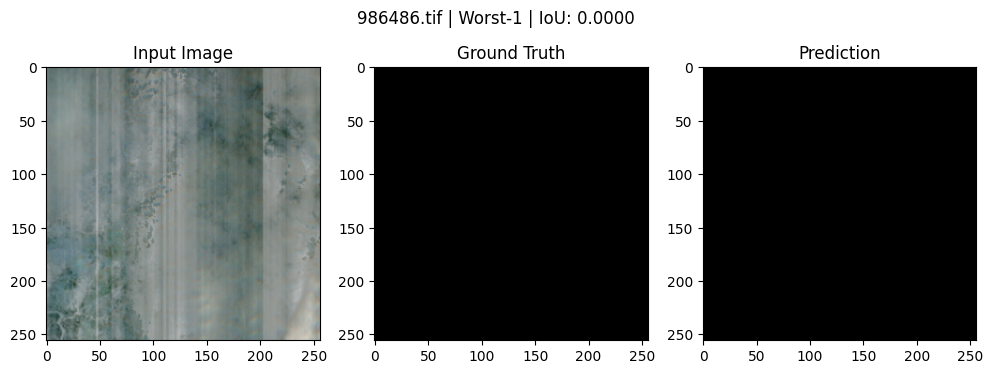

Unique values for 986486.tif:
Ground Truth Mask (True): [0]
Prediction Mask (Pred): [1]


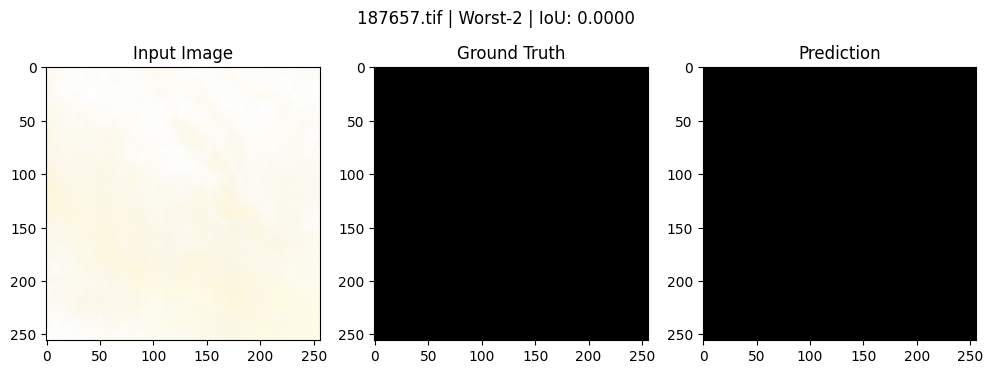

Unique values for 187657.tif:
Ground Truth Mask (True): [1]
Prediction Mask (Pred): [0]


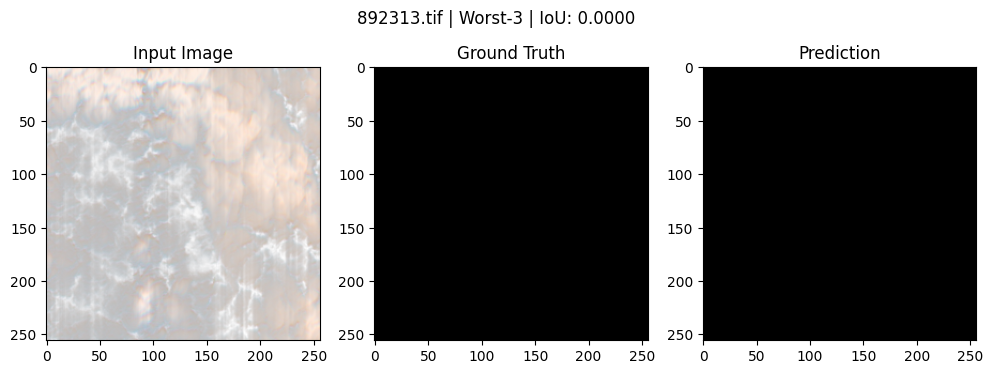

Unique values for 892313.tif:
Ground Truth Mask (True): [0]
Prediction Mask (Pred): [1]


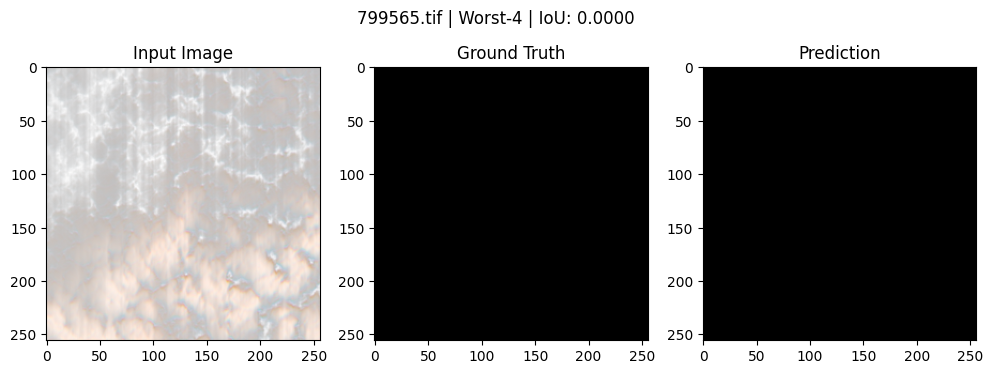

Unique values for 799565.tif:
Ground Truth Mask (True): [0]
Prediction Mask (Pred): [1]


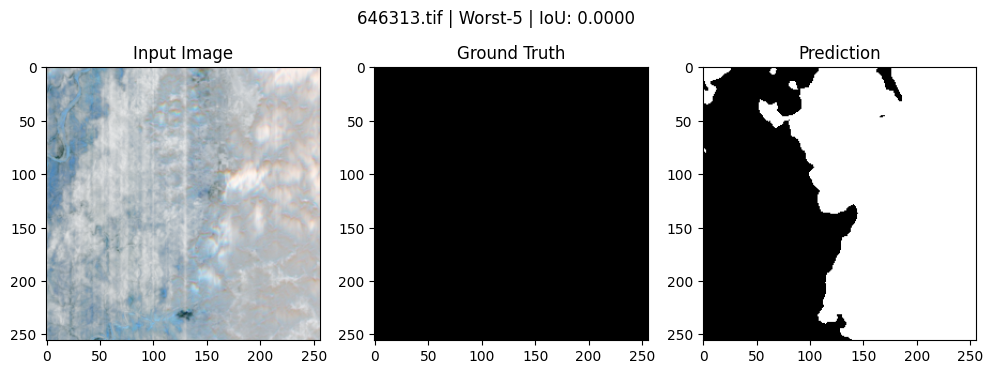

Unique values for 646313.tif:
Ground Truth Mask (True): [0]
Prediction Mask (Pred): [0 1]


In [ ]:
show_worst_predictions(worst_results, k=5)

### Results
- We notice that almost all cases the model failed to get were the already **mislabeled masks**
    - The model could find that the image had a **white overlay** so it seems like a cloud
    - Although the ground truth mask is full of **zeros**

## Fixing Mislabeled Masks
- Here we get the masks that the model has a very low IOU with
    -  As they indicate something can be wrong with the mask

In [ ]:
# Get the list of filenames where IoU = 0
threshold = 1e-10
zero_iou_filenames = [
    result["filename"] for result in worst_results if result["iou"] <= threshold
]
# Print the list
print(zero_iou_filenames)
len(zero_iou_filenames)

## Evaluation

In [ ]:
combined_dataset = ConcatDataset([val_loader.dataset, test_loader.dataset])
combined_loader = DataLoader(
    combined_dataset, batch_size=test_loader.batch_size, shuffle=False, num_workers=4
)

In [ ]:
dice_score = evaluate_dice_score(model, full_data_loader, device)
dice_score

In [32]:
torch.save(model, "full_model.pth")